In [1]:
pip install util-gfsilveira

In [2]:
#gerar gráfico
import matplotlib
#estruturação dos dados
import numpy as np
#gerar gráfico
import seaborn as sns
#gerar gráfico
import matplotlib.pyplot as plt
#Carregar o modelo
from keras.models import load_model
#salvar/carregar arquivos em diferentes formatos
import joblib

In [3]:
#Importando o modelo contendo os valores previstos para o número de células nas imagens
modelo_maior_erro = load_model('/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos - fluorescencia/img_e_rot_para_validação_fluorescencia/imagens rotulo modelo - validação fluorescencia/modelo_fluore_2024-9-30.keras')
modelo_maior_erro

<Sequential name=sequential, built=True>

In [4]:
X_test_maior_erro = joblib.load('/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos HUVEC/realçadas/lista_imagem_angulacoes_HUVEC_realce_2025-7-15.gz') #carregando arquivo
X_test_maior_erro.shape

(148, 300, 300, 3)

In [5]:
# y_test_maior_erro = joblib.load('/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/img_e_rot_para_validação_contraste/rótulos_validação_10%_fluore_2024-9-10.gz') #carregando arquivo
# y_test_maior_erro.shape

In [6]:
# #ROTULOS SALVOS EM LISTA

# lista_observado_maior_erro = list(y_test_maior_erro)
# len(lista_observado_maior_erro)

In [7]:
#PREDIÇÃO SALVO EM LISTA

dados_prev = modelo_maior_erro.predict(X_test_maior_erro)
lista_previsto_maior_erro = dados_prev.flatten().tolist()
len(lista_previsto_maior_erro)

5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step


148

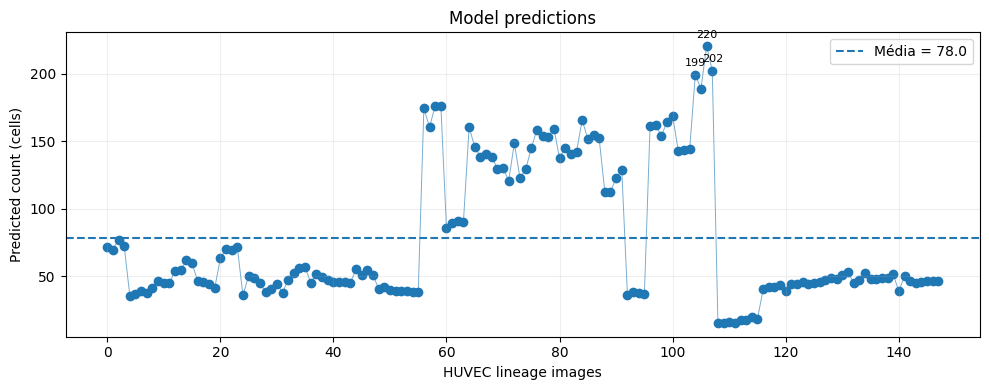

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Substitua por sua lista de previsões
preds = lista_previsto_maior_erro  # por ex: [12, 15, 9, ...]

preds = np.asarray(preds, dtype=float)
x = np.arange(len(preds))

plt.figure(figsize=(10,4))
plt.scatter(x, preds)
plt.plot(x, preds, linewidth=0.7, alpha=0.6)         # linha opcional para visualizar tendência
plt.axhline(preds.mean(), linestyle='--', label=f"Média = {preds.mean():.1f}")

# anotar os 3 maiores valores
anotar_top = 3
idxs = np.argsort(preds)[-anotar_top:][::-1]
for i in idxs:
    plt.annotate(f"{preds[i]:.0f}", (x[i], preds[i]), xytext=(0,6), textcoords="offset points", ha='center', fontsize=8)

plt.xlabel("HUVEC lineage images")
plt.ylabel("Predicted count (cells)")
plt.title("Model predictions")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
lista_previsto_treino = [75.24390411376953,59.963932037353516,128.0557098388672,138.27383422851562,69.06813049316406,96.67308807373047,95.46122741699219,162.57791137695312,150.1357879638672,107.95465087890625,
 63.19172286987305,119.45916748046875,39.75974655151367,57.212886810302734,89.5084228515625,98.2818603515625,69.75218200683594,91.22416687011719,74.62808227539062,92.09198760986328,101.88642883300781,127.1731948852539,
 53.51933670043945,58.079734802246094,47.91412353515625,104.4388198852539,129.21432495117188,111.45118713378906,32.22316360473633,102.15168762207031,104.95410919189453,54.28751754760742,70.4607162475586,
 74.89276885986328,68.18036651611328,93.23050689697266,65.0656967163086,49.46275329589844,63.80855941772461,59.224788665771484,38.399471282958984,61.03938674926758,65.95758056640625,46.61861801147461,31.207252502441406,
 37.05534744262695,26.51272201538086,43.150753021240234,32.27516174316406,27.15099334716797,44.375919342041016,19.24840545654297,21.17153549194336,25.187456130981445,17.11870574951172,28.180419921875,37.41416549682617,
 17.069948196411133,31.613685607910156,38.72479248046875,52.37337112426758,33.87430953979492,26.40349769592285,30.554105758666992]

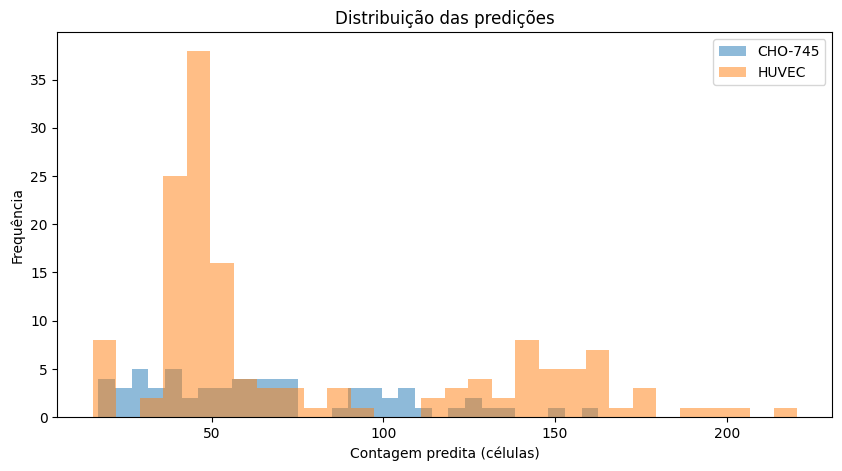

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(lista_previsto_treino, bins=30, alpha=0.5, label="CHO-745")
plt.hist(lista_previsto_maior_erro, bins=30, alpha=0.5, label="HUVEC")
plt.xlabel("Contagem predita (células)")
plt.ylabel("Frequência")
plt.title("Distribuição das predições")
plt.legend()
plt.show()

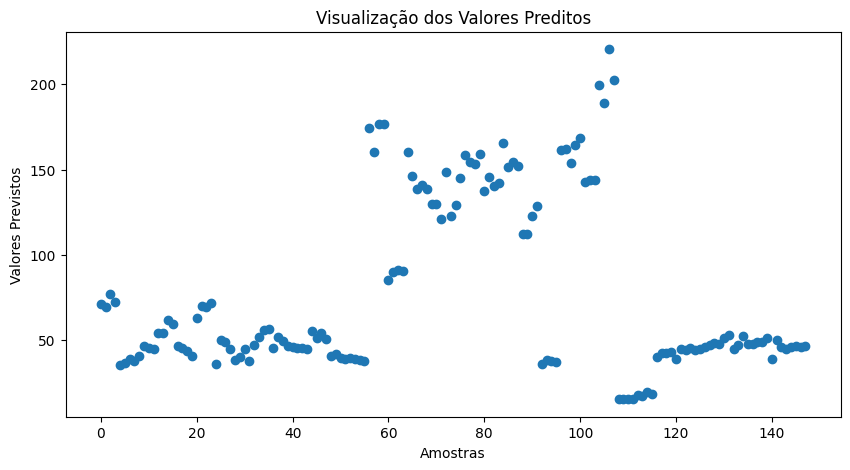

In [11]:
# Visualizar previsões
plt.figure(figsize=(10, 5))
plt.plot(lista_previsto_maior_erro, marker='o', linestyle='')
plt.xlabel("Amostras")
plt.ylabel("Valores Previstos")
plt.title("Visualização dos Valores Preditos")
plt.show()

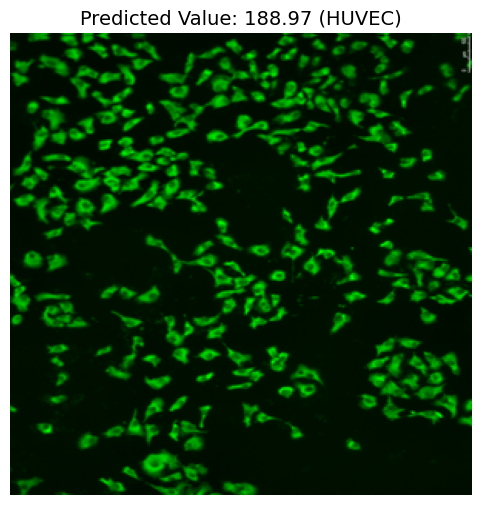

In [12]:
# Exibir uma imagem com o valor predito
indice_amostra = 105  # Escolher um índice de amostra para visualizar
imagem_exibida = X_test_maior_erro[indice_amostra]
valor_predito = lista_previsto_maior_erro[indice_amostra]

plt.figure(figsize=(6, 6))
plt.imshow(imagem_exibida.squeeze(), cmap='gray')  # Certifica-se de que a imagem está em escala de cinza
plt.title(f"Predicted Value: {valor_predito:.2f} (HUVEC)", fontsize=14)
plt.axis("off")
plt.show()


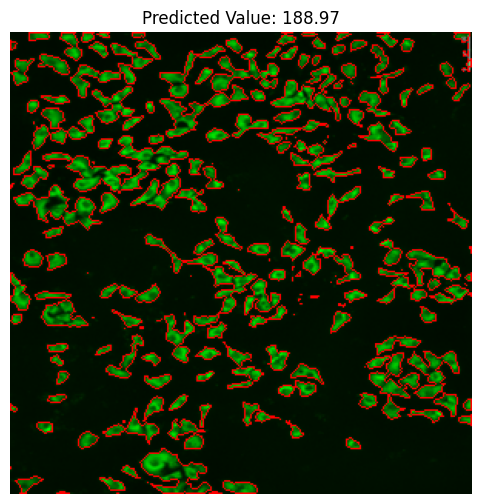

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Exemplo: usando a imagem já carregada em imagem_exibida
indice_amostra = 105  # índice escolhido
imagem_exibida = X_test_maior_erro[indice_amostra]
valor_predito = lista_previsto_maior_erro[indice_amostra]

# Se a imagem estiver em float [0,1], converter para uint8 [0,255]
if imagem_exibida.max() <= 1.0:
    img_uint8 = (imagem_exibida * 255).astype(np.uint8)
else:
    img_uint8 = imagem_exibida.astype(np.uint8)

# Converter de RGB para BGR (OpenCV usa BGR)
img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)

# Converter para HSV
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Intervalo para detectar o verde (ajuste se necessário)
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])

# Criar máscara
mask = cv2.inRange(hsv, lower_green, upper_green)

# Encontrar contornos
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Desenhar contornos em vermelho
img_contours = img_bgr.copy()
cv2.drawContours(img_contours, contours, -1, (0, 0, 255), 1)

# Converter de volta para RGB para exibir com matplotlib
img_rgb = cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB)

# Exibir
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title(f'Predicted Value: {valor_predito:.2f}')
plt.axis('off')
plt.show()



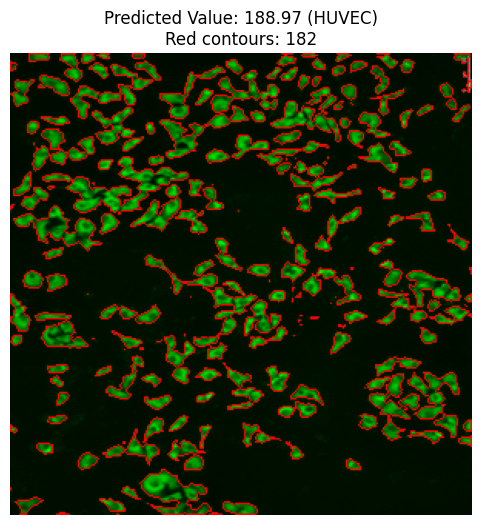

Quantidade de contornos detectados (verdes contornados em vermelho): 182


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Exemplo usando sua imagem já carregada em array NumPy
indice_amostra = 105  # índice de exemplo
imagem_exibida = X_test_maior_erro[indice_amostra]
valor_predito = lista_previsto_maior_erro[indice_amostra]

# Garantir que a imagem esteja no formato uint8 [0,255]
if imagem_exibida.max() <= 1.0:
    img_uint8 = (imagem_exibida * 255).astype(np.uint8)
else:
    img_uint8 = imagem_exibida.astype(np.uint8)

# Converter de RGB para BGR para uso com OpenCV
img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)

# Converter para HSV
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Intervalo para detectar verde (ajuste conforme necessário)
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])

# Criar máscara para pixels verdes
mask = cv2.inRange(hsv, lower_green, upper_green)

# Encontrar contornos
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Contar contornos
num_contornos = len(contours)

# Desenhar contornos em vermelho
img_contours = img_bgr.copy()
cv2.drawContours(img_contours, contours, -1, (0, 0, 255), 1)

# Converter de volta para RGB para exibição
img_rgb = cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB)

# Exibir imagem e quantidade de contornos
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title(f'Predicted Value: {valor_predito:.2f} (HUVEC)\nRed contours: {num_contornos}')
plt.axis('off')
plt.show()

print(f"Quantidade de contornos detectados (verdes contornados em vermelho): {num_contornos}")


Total de previsões: 148

📊 Estatísticas descritivas:
n amostras               148.000000
média                     78.027631
mediana                   49.815189
desvio padrão             51.221997
mínimo                    15.364311
máximo                   220.497375
Q1                        43.957144
Q3                       129.284004
IQR                       85.326860
assimetria (skewness)      0.919787
curtose                   -0.574211
dtype: float64


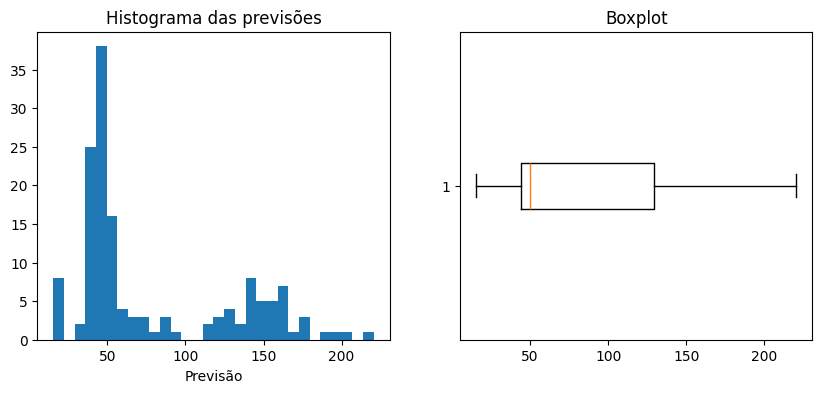


🔍 Outliers (IQR): 0
🔍 Outliers (Z-score > 3): 0
🔍 Outliers (Isolation Forest): 2

📈 BIC por número de componentes:
{1: np.float64(1594.1028818234824), 2: np.float64(1446.045903683091), 3: np.float64(1454.455211042564)}
➡️ Melhor número de componentes (menor BIC): 2

📉 Média estimada: 78.100 (IC 95%: (np.float64(70.02015348640649), np.float64(86.4256875643859)))
📉 Mediana estimada: 49.903 (IC 95%: (np.float64(46.753610610961914), np.float64(54.34188652038574)))


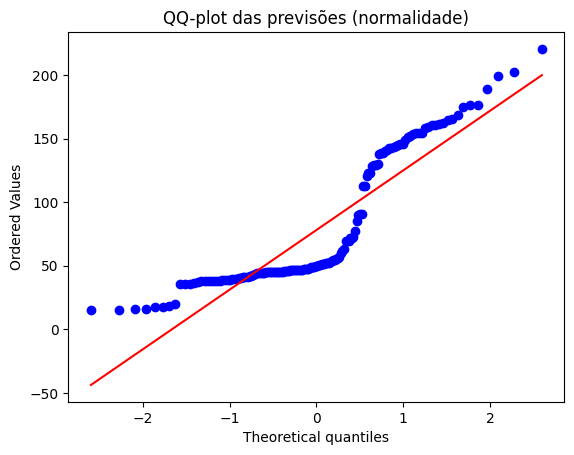


📋 Interpretação inicial:
- Se muitos outliers: revisar imagens correspondentes (podem ser artefatos).
- Se BIC mínimo > 1 componente: há chance de subgrupos (ex: imagens com confluência diferente).
- Skewness positiva → cauda à direita (previsões altas esparsas).
- Curtose alta (>3) → distribuição mais pontuda (poucas previsões dominam).
- Use ICs da média/mediana para descrever intervalo de confiança dos resultados.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture

# =====================================================
# 1. Converter lista para array NumPy
# =====================================================
y = np.array(lista_previsto_maior_erro).flatten()
print(f"Total de previsões: {len(y)}")

# =====================================================
# 2. Estatística descritiva
# =====================================================
desc = {
    'n amostras': len(y),
    'média': np.mean(y),
    'mediana': np.median(y),
    'desvio padrão': np.std(y, ddof=1),
    'mínimo': np.min(y),
    'máximo': np.max(y),
    'Q1': np.percentile(y, 25),
    'Q3': np.percentile(y, 75),
    'IQR': np.percentile(y, 75) - np.percentile(y, 25),
    'assimetria (skewness)': stats.skew(y),
    'curtose': stats.kurtosis(y)
}
print("\n📊 Estatísticas descritivas:")
print(pd.Series(desc))

# =====================================================
# 3. Distribuição: histograma + boxplot
# =====================================================
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(y, bins=30)
plt.xlabel('Previsão'); plt.title('Histograma das previsões')

plt.subplot(1, 2, 2)
plt.boxplot(y, vert=False)
plt.title('Boxplot')
plt.show()

# =====================================================
# 4. Outliers por IQR e Z-score
# =====================================================
q1, q3 = np.percentile(y, [25, 75])
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
outliers_iqr = np.where((y < limite_inferior) | (y > limite_superior))[0]
z = np.abs(stats.zscore(y))
outliers_z = np.where(z > 3)[0]

print(f"\n🔍 Outliers (IQR): {len(outliers_iqr)}")
print(f"🔍 Outliers (Z-score > 3): {len(outliers_z)}")

# =====================================================
# 5. Outliers por Isolation Forest
# =====================================================
iso = IsolationForest(contamination=0.01, random_state=42)
labels_iso = iso.fit_predict(y.reshape(-1, 1))
outliers_iso = np.where(labels_iso == -1)[0]
print(f"🔍 Outliers (Isolation Forest): {len(outliers_iso)}")

# =====================================================
# 6. Multimodalidade via GMM (1 a 3 componentes)
# =====================================================
bics = {}
for k in [1, 2, 3]:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(y.reshape(-1, 1))
    bics[k] = gmm.bic(y.reshape(-1, 1))

melhor_k = min(bics, key=bics.get)
print("\n📈 BIC por número de componentes:")
print(bics)
print(f"➡️ Melhor número de componentes (menor BIC): {melhor_k}")

# =====================================================
# 7. Bootstrap para IC da média e mediana
# =====================================================
def bootstrap_ci(data, statfunc=np.mean, n_boot=5000, alpha=0.05):
    rng = np.random.default_rng(0)
    stats_bs = [statfunc(rng.choice(data, size=len(data), replace=True))
                for _ in range(n_boot)]
    lo = np.percentile(stats_bs, 100 * alpha / 2)
    hi = np.percentile(stats_bs, 100 * (1 - alpha / 2))
    return np.mean(stats_bs), (lo, hi)

mean_bs, mean_ci = bootstrap_ci(y, np.mean)
med_bs, med_ci = bootstrap_ci(y, np.median)

print(f"\n📉 Média estimada: {mean_bs:.3f} (IC 95%: {mean_ci})")
print(f"📉 Mediana estimada: {med_bs:.3f} (IC 95%: {med_ci})")

# =====================================================
# 8. QQ-plot (normalidade)
# =====================================================
plt.figure()
stats.probplot(y, dist="norm", plot=plt)
plt.title("QQ-plot das previsões (normalidade)")
plt.show()

# =====================================================
# 9. Interpretação resumida
# =====================================================
print("\n📋 Interpretação inicial:")
print("- Se muitos outliers: revisar imagens correspondentes (podem ser artefatos).")
print("- Se BIC mínimo > 1 componente: há chance de subgrupos (ex: imagens com confluência diferente).")
print("- Skewness positiva → cauda à direita (previsões altas esparsas).")
print("- Curtose alta (>3) → distribuição mais pontuda (poucas previsões dominam).")
print("- Use ICs da média/mediana para descrever intervalo de confiança dos resultados.")


QQ-plot: Conclusão: o modelo gera valores com distribuição não normal — portanto, análises paramétricas (como t-test) não são adequadas. Devem-se usar testes não paramétricos (como Mann–Whitney U, Kruskal–Wallis, ou correlação de Spearman).

Outliers: Conclusão: seus dados de previsão estão bem comportados, sem grandes outliers que possam distorcer análises.

BIC (Bayesian Information Criterion): Conclusão: o melhor modelo é com 2 componentes, sugerindo duas distribuições principais nas previsões (por exemplo, dois padrões distintos de contagem celular nas imagens).

Estatísticas descritivas: A média é maior que a mediana → a distribuição é assimétrica à direita (valores maiores puxam a média). Isso confirma o que o QQ-plot já sugeria: não normalidade e cauda longa positiva.